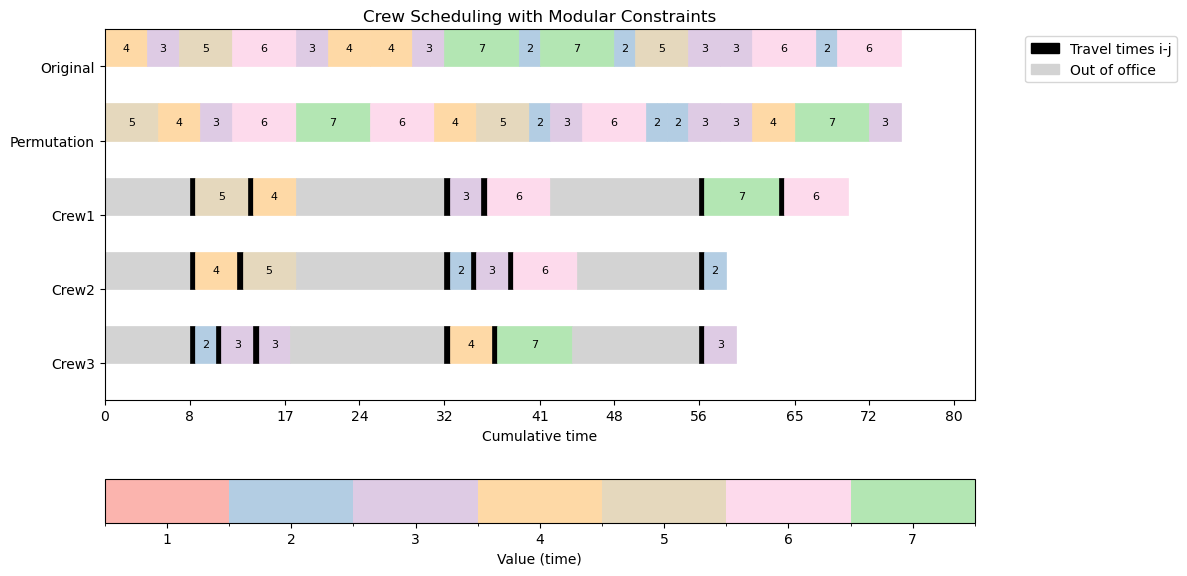

In [6]:
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.patches as mpatches

# -----------------------------
# 1. Parameters and data
# -----------------------------
xticks = [0, 8, 17, 24, 32, 41, 48, 56, 65, 72, 80]

# random values between 1 and 7
nums = [random.randint(1, 7) for _ in range(18)]

# permutation
perm = nums.copy()
random.shuffle(perm)

# crews: 6, 6, 6
crew1 = perm[:6]
crew2 = perm[6:12]
crew3 = perm[12:]

# -----------------------------
# 2. Custom colormap (7 = light green)
# -----------------------------
base = plt.get_cmap('Pastel1', 7)
colors = [base(i) for i in range(7)]

# override value 7 color
colors[-1] = (0.7, 0.9, 0.7, 1.0)  # light green

cmap = mcolors.ListedColormap(colors)

bounds = np.arange(1, 9) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# -----------------------------
# 3. Plot setup
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# -----------------------------
# 4. Draw normal rows
# -----------------------------
def draw_row(values, y):
    x = 0
    for v in values:
        rect = plt.Rectangle((x, y), v, 1,
                             color=cmap(v-1),
                             #edgecolor='black',
                             linewidth=0.5)
        ax.add_patch(rect)

        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)

        x += v
    return x

# -----------------------------
# 5. Draw crew rows
# -----------------------------
def draw_crew(values, y, start_x=8):
    # Initial "out of office" (0 → 8)
    ax.add_patch(plt.Rectangle(
        (0, y), 8, 1,
        color='lightgray',
        #edgecolor='black',
        linewidth=0.5
    ))

    x = start_x

    for i, v in enumerate(values):
        # black spacer (travel time)
        ax.add_patch(plt.Rectangle(
            (x, y), 0.5, 1,
            color='black',
            #edgecolor='black',
            linewidth=0.5
        ))
        x += 0.5

        # value block
        ax.add_patch(plt.Rectangle(
            (x, y), v, 1,
            color=cmap(v-1),
            #edgecolor='black',
            linewidth=0.5
        ))

        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)

        x += v

        # modular interruption rule (only if not last value!)
        if i < len(values) - 1 and (x % 24) >= 17:
            delta = (8 - (x % 24)) % 24
            if delta > 0:
                ax.add_patch(plt.Rectangle(
                    (x, y), delta, 1,
                    color='lightgray',
                    #edgecolor='black',
                    linewidth=0.5
                ))
                x += delta

    return x

# -----------------------------
# 6. Draw all rows
# -----------------------------
w1 = draw_row(nums, 3)
w2 = draw_row(perm, 1)

w3 = draw_crew(crew1, -1)
w4 = draw_crew(crew2, -3)
w5 = draw_crew(crew3, -5)

max_width = max(w1, w2, w3, w4, w5)

# -----------------------------
# 7. Colorbar (bottom)
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    pad=0.15,
    ticks=range(1, 8)
)

cbar.set_label("Value (time)")

# -----------------------------
# 8. Legend (outside right)
# -----------------------------
black_patch = mpatches.Patch(
    color='black',
    label='Travel times i-j'
)

gray_patch = mpatches.Patch(
    color='lightgray',
    label='Out of office'
)

ax.legend(
    handles=[black_patch, gray_patch],
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# -----------------------------
# 9. Axes
# -----------------------------
ax.set_xticks(xticks)
ax.set_xlim(0, max(max_width + 2, 82))

ax.set_ylim(-6, 4)
ax.set_yticks([3, 1, -1, -3, -5])
ax.set_yticklabels([
    "Original",
    "Permutation",
    "Crew1",
    "Crew2",
    "Crew3"
])

ax.set_xlabel("Cumulative time")
ax.set_title("Crew Scheduling with Modular Constraints")

# -----------------------------
# 10. Show plot
# -----------------------------
plt.tight_layout()
plt.show()